# How to Win the VN1 Competition

- Weekly retail dataset with 15,053 series and a forecast horizon of 13 weeks. 

- Organized by Nicolas Vandeput on the [datasource.ai](https://www.datasource.ai/en) platform from September to October 2024. 

## Load data

In [ ]:
import pandas as pd 
from utilsforecast.plotting import plot_series
from utilsforecast.preprocessing import fill_gaps

In [2]:
# Competition had two phases and participants needed to forecast sales for the third
train_phase0 = pd.read_csv(f'../data/Phase 0 - Sales.csv')
train_phase0.head()

,Client,Warehouse,Product,2020-07-06,2020-07-13,2020-07-20,2020-07-27,2020-08-03,2020-08-10,2020-08-17,...,2023-07-31,2023-08-07,2023-08-14,2023-08-21,2023-08-28,2023-09-04,2023-09-11,2023-09-18,2023-09-25,2023-10-02
0,0,1,367,7.0,7.0,7.0,7.0,7.0,7.0,7.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,7.0,0.0
1,0,1,639,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,5.0,5.0,6.0,5.0,1.0,2.0,2.0,18.0,2.0
2,0,1,655,21.0,21.0,21.0,25.0,35.0,35.0,35.0,...,9.0,4.0,2.0,9.0,8.0,6.0,0.0,17.0,21.0,37.0
3,0,1,1149,7.0,7.0,7.0,7.0,7.0,7.0,7.0,...,1.0,1.0,1.0,0.0,2.0,2.0,2.0,1.0,0.0,1.0
4,0,1,1485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,21.0,23.0,2.0,1.0,1.0,2.0,0.0,22.0,10.0,6.0


In [3]:
# Competition datasets 
from utils import load_and_transform

train_phase0 = load_and_transform('Phase 0 - Sales', 'y')
train_phase1 = load_and_transform('Phase 1 - Sales', 'y')

train_df = pd.concat([train_phase0, train_phase1], axis=0)
train_df = train_df.sort_values(by=['unique_id', 'ds'])
train_df['ds'] = pd.to_datetime(train_df['ds'])
train_df.head()

,unique_id,ds,y
0,0-1-10705,2020-07-06,7.0
1,0-1-10705,2020-07-13,7.0
2,0-1-10705,2020-07-20,7.0
3,0-1-10705,2020-07-27,7.0
4,0-1-10705,2020-08-03,7.0


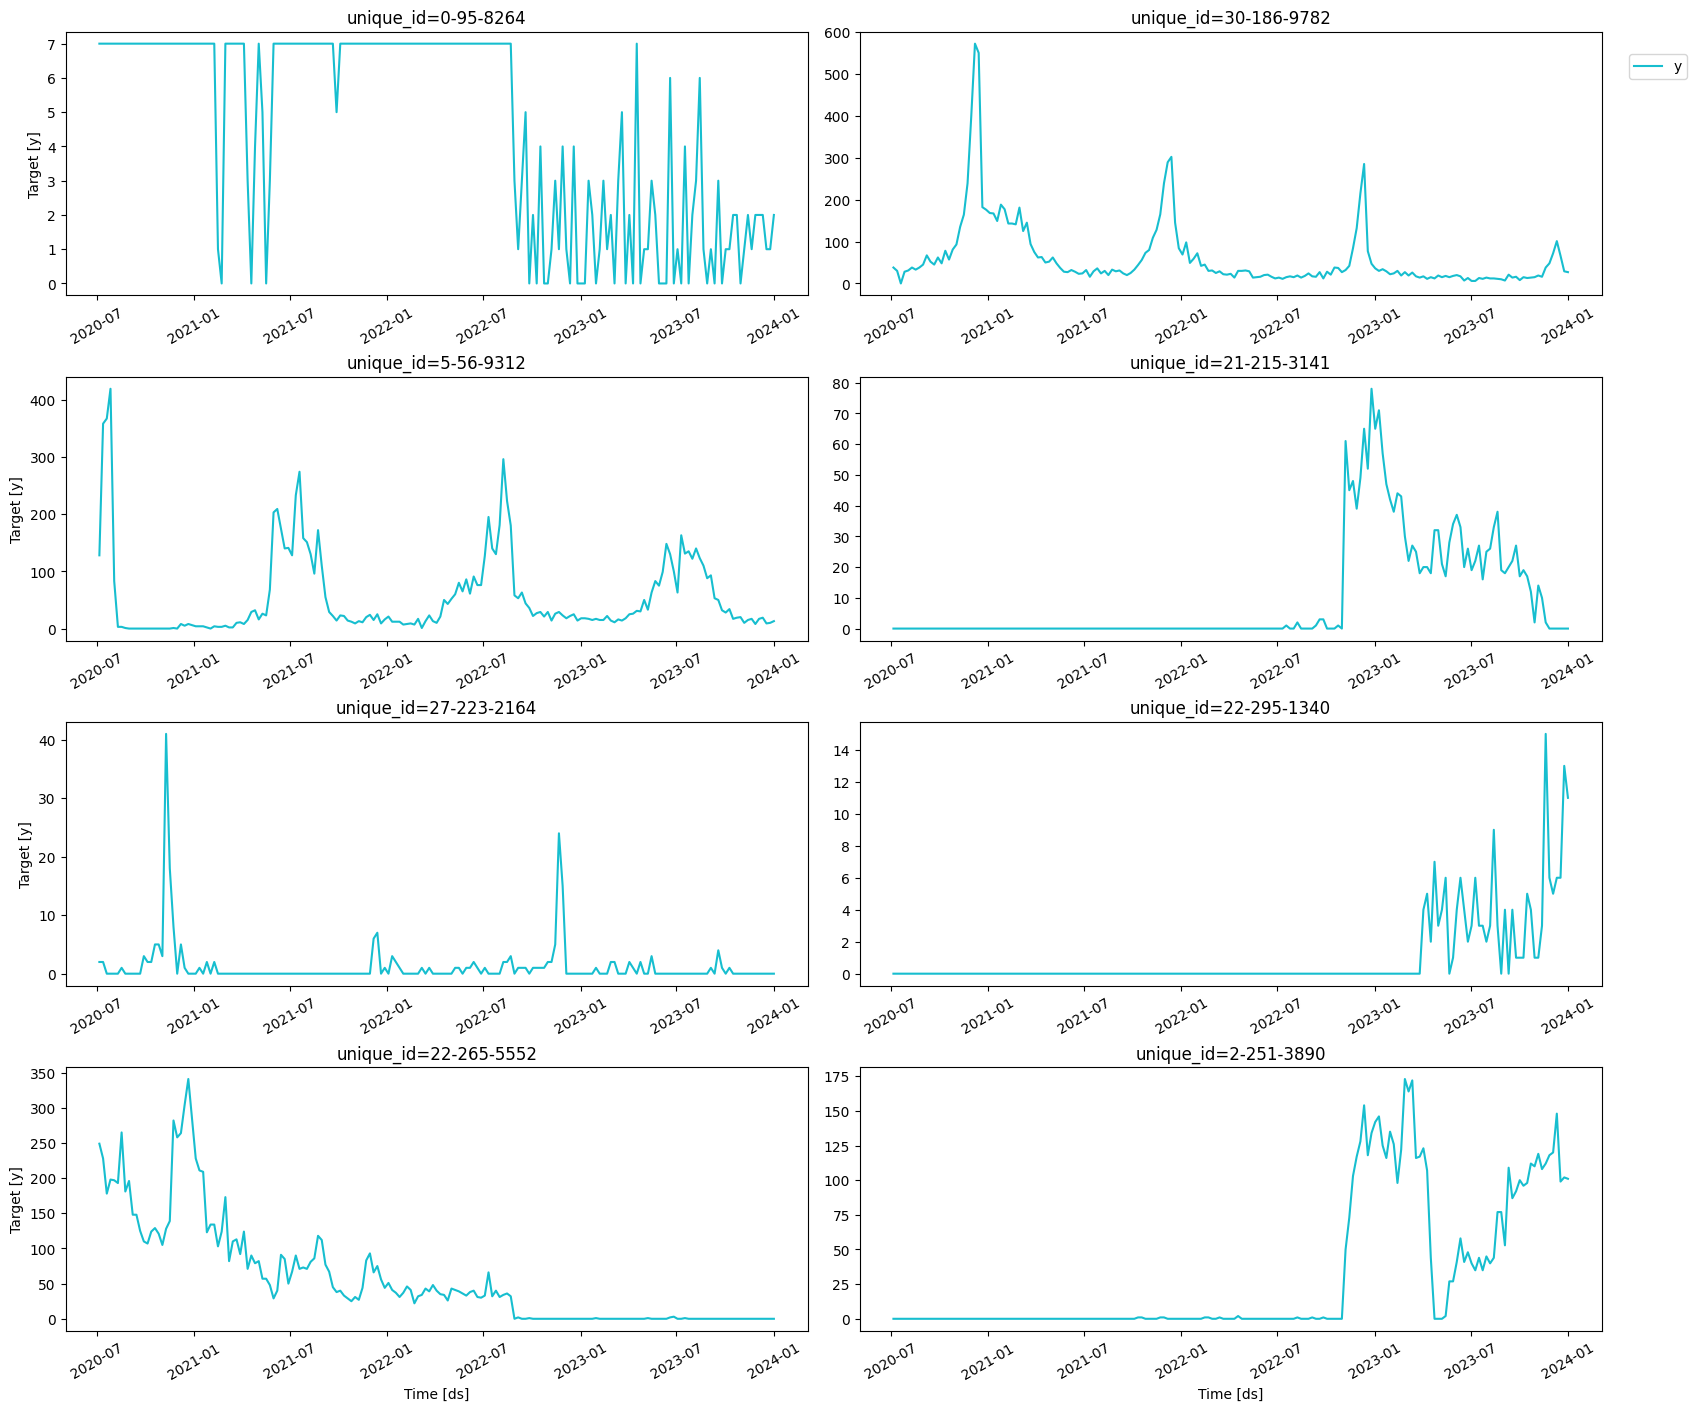

In [4]:
plot_series(train_df)

## Data pre-processing 

- Fill missing dates (required)

- Check for missing values (required)

- Remove leading zeros (recommended)

In [5]:
train_df['ds'].unique()[1:5] # weekly data that starts on Monday 

<DatetimeArray>
['2020-07-13 00:00:00', '2020-07-20 00:00:00', '2020-07-27 00:00:00',
 '2020-08-03 00:00:00']
Length: 4, dtype: datetime64[ns]

In [6]:
train_complete = fill_gaps(  
    train_df, 
    freq='W-MON',
    start='per_serie', 
    end='global'
)

train_complete.isna().any()

unique_id    False
ds           False
y            False
dtype: bool

In [7]:
def remove_leading_zeros(group): 
    """
    Removes leading zeros from each series 
    """
    first_non_zero_index = group['y'].ne(0).idxmax()
    return group.loc[first_non_zero_index:]

train_clean = train_complete.groupby('unique_id').apply(remove_leading_zeros).reset_index(drop=True)

train_clean.shape[0], train_complete.shape[0]

/var/folders/0g/82x8ml8d55q88d1yftnwk_jw0000gn/T/ipykernel_40114/1407338568.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_clean = train_complete.groupby('unique_id').apply(remove_leading_zeros).reset_index(drop=True)


(1615437, 2754699)

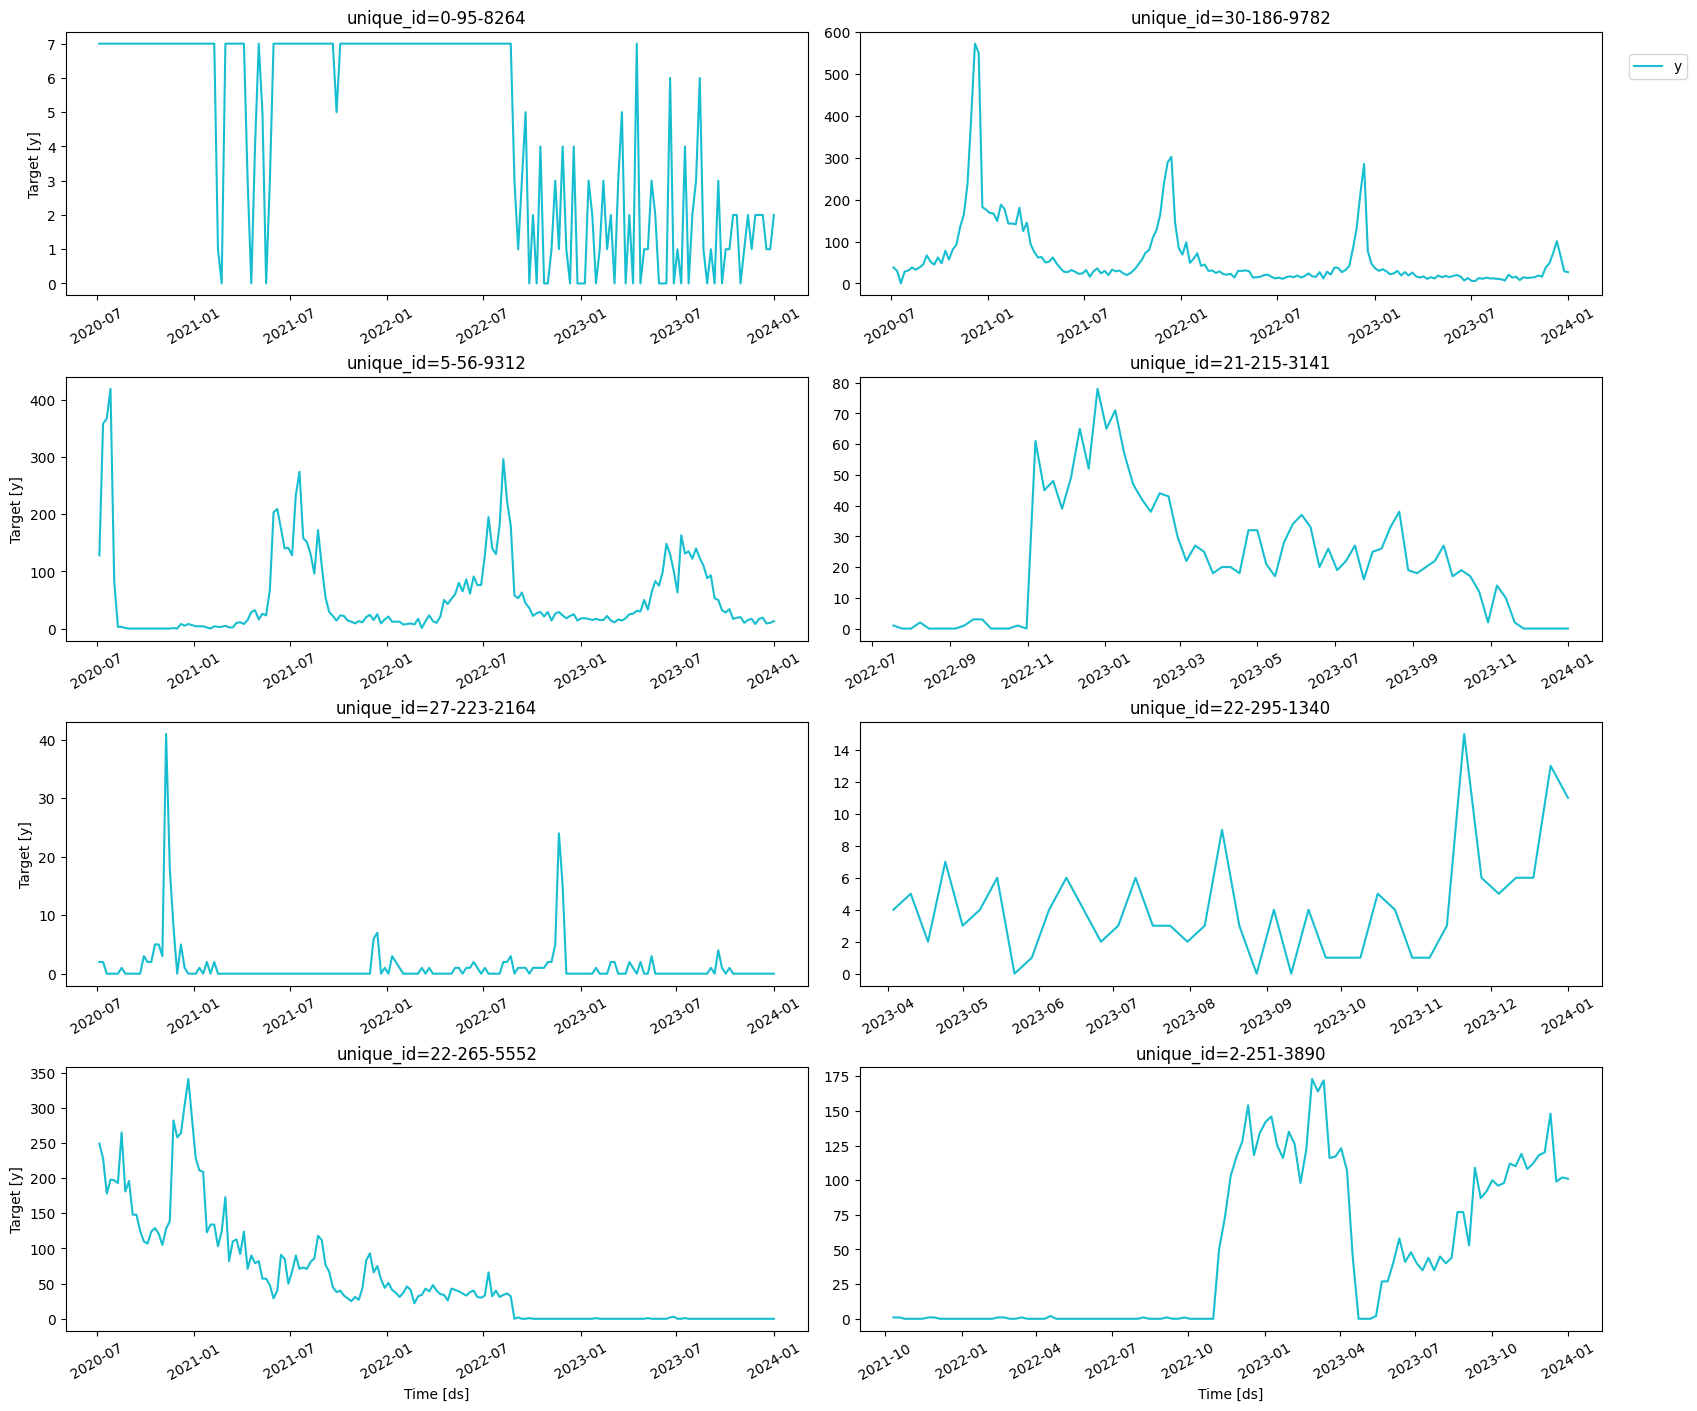

In [8]:
plot_series(train_clean)

In [9]:
print('Number of time series: ', train_clean['unique_id'].nunique())
print('Start date: ', train_clean['ds'].min())
print('End date: ', train_clean['ds'].max())

Number of time series:  15053
Start date:  2020-07-06 00:00:00
End date:  2024-01-01 00:00:00


In [10]:
train_clean.to_parquet('../data_prepared/df.parquet')

## Actual competition winners 

$$\text{VN1 score} = \dfrac{\text{absolute\_error} + \lvert \text{error} \rvert}{\sum_{i=1}^{T} y_i}$$

Where

$$\text{absolute\_error} = \sum_{i=1}^{T} \lvert \hat{y}_i - y_i \rvert$$

$$\text{error} = \sum_{i=1}^{T} (\hat{y}_i - y_i)$$

Here 
- $T$ is the number of periods to forecast (13 weeks).
- $y_i$ is the actual value.
- $\hat{y}_i$ is the forecasted value.

In [11]:
from utils import vn1_competition_evaluation
from functools import reduce

places = ['1st', '2nd', '3rd', '4th', '5th']

dfs = [load_and_transform(f'Solution {place} place', f'{place} place') for place in places]

competition_winners = reduce(
    lambda left, right: left.merge(right, on=["unique_id", "ds"], how="left"),
    dfs,
)

competition_winners['ds'] = pd.to_datetime(competition_winners['ds'])

competition_winners.head()

,unique_id,ds,1st place,2nd place,3rd place,4th place,5th place
0,0-1-10705,2024-01-08,2.678368,1.927868,1.921462,2,3.269620
1,0-1-10705,2024-01-15,2.606428,2.094381,2.149602,2,3.182701
2,0-1-10705,2024-01-22,2.613300,2.317105,2.110164,2,3.387433
3,0-1-10705,2024-01-29,2.797461,2.332724,2.516306,2,3.596637
4,0-1-10705,2024-02-05,2.680118,2.102612,2.098589,2,3.452159


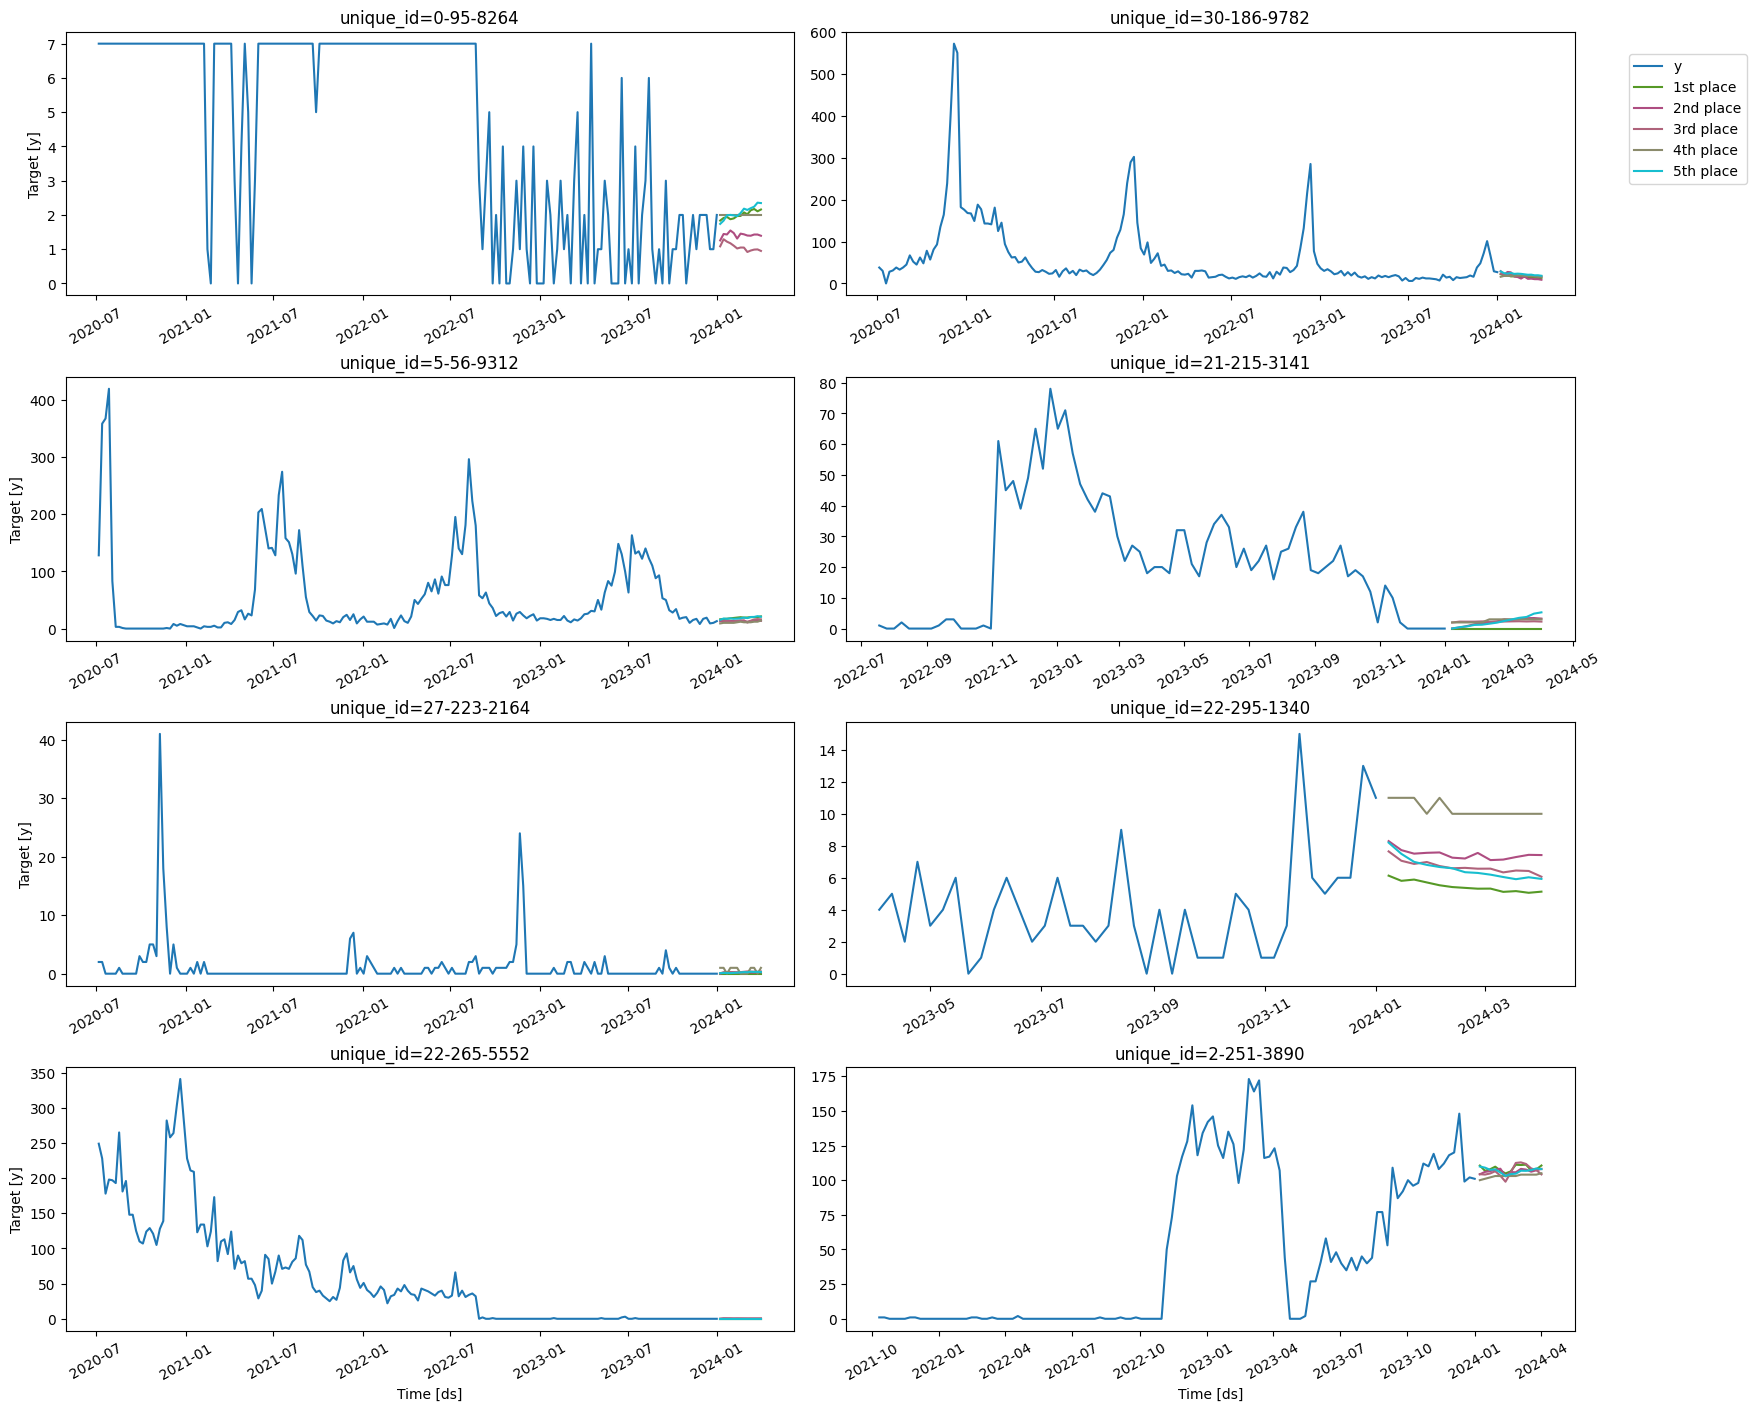

In [12]:
plot_series(
    train_clean, 
    competition_winners
)

In [13]:
winners_scores =vn1_competition_evaluation(competition_winners)
winners_scores

,model,score
0,1st place,0.46375
1,2nd place,0.46568
2,3rd place,0.47578
3,4th place,0.47743
4,5th place,0.48081


In [14]:
winners_scores.to_parquet('../scores/winners_scores.parquet')